In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
import gymnasium as gym
import ale_py
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack
from stable_baselines3.common.atari_wrappers import AtariWrapper
from stable_baselines3.common.callbacks import BaseCallback
 
gym.register_envs(ale_py)

2026-05-21 21:56:20.751186: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-21 21:56:20.751548: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-21 21:56:20.781114: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-21 21:56:21.752561: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computat

## Environment inspection 

In [2]:
env = gym.make("ALE/MsPacman-v5")
obs, info = env.reset()

print("=== SPACES ===")
print("Obs space:", env.observation_space)
print("Act space:", env.action_space)
print("Actions:", env.unwrapped.get_action_meanings())

print("\n=== INFO DICT KEYS ===")
print(info)

print("\n=== ALE PROPERTIES ===")
ale = env.unwrapped.ale
print("Lives:", ale.lives())
print("Frame number:", ale.getFrameNumber())
print("Episode frames:", ale.getEpisodeFrameNumber())
print("RAM size:", len(ale.getRAM()))
print("Legal actions:", ale.getLegalActionSet())
print("Min actions:", ale.getMinimalActionSet())

env.close()

=== SPACES ===
Obs space: Box(0, 255, (210, 160, 3), uint8)
Act space: Discrete(9)
Actions: ['NOOP', 'UP', 'RIGHT', 'LEFT', 'DOWN', 'UPRIGHT', 'UPLEFT', 'DOWNRIGHT', 'DOWNLEFT']

=== INFO DICT KEYS ===
{'lives': 3, 'episode_frame_number': 0, 'frame_number': 0}

=== ALE PROPERTIES ===
Lives: 3
Frame number: 0
Episode frames: 0
RAM size: 128
Legal actions: [<Action.NOOP: 0>, <Action.FIRE: 1>, <Action.UP: 2>, <Action.RIGHT: 3>, <Action.LEFT: 4>, <Action.DOWN: 5>, <Action.UPRIGHT: 6>, <Action.UPLEFT: 7>, <Action.DOWNRIGHT: 8>, <Action.DOWNLEFT: 9>, <Action.UPFIRE: 10>, <Action.RIGHTFIRE: 11>, <Action.LEFTFIRE: 12>, <Action.DOWNFIRE: 13>, <Action.UPRIGHTFIRE: 14>, <Action.UPLEFTFIRE: 15>, <Action.DOWNRIGHTFIRE: 16>, <Action.DOWNLEFTFIRE: 17>]
Min actions: [<Action.NOOP: 0>, <Action.UP: 2>, <Action.RIGHT: 3>, <Action.LEFT: 4>, <Action.DOWN: 5>, <Action.UPRIGHT: 6>, <Action.UPLEFT: 7>, <Action.DOWNRIGHT: 8>, <Action.DOWNLEFT: 9>]


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


In [3]:
import torch
print(torch.__version__)        
print(torch.cuda.is_available()) 

2.10.0+cpu
False


## Reward Shaping Wrapper

In [4]:
class RewardShapingWrapper(gym.Wrapper):
    GHOST_REWARDS = {200, 400, 800, 1600}
    FRUIT_REWARDS = {100, 300, 500, 700, 1000, 2000, 3000, 5000}
    POWER_PELLET_REWARD = 50
    REGULAR_PELLET_REWARD = 10
    POWER_PELLET_DURATION = 150  
 
    def __init__(
        self,
        env,
        ghost_chain_bonus = 12.0,
        pellet_streak_bonus = 0.03,
        fruit_multiplier = 1.05,
        death_penalty = 0.0,
    ):
        super().__init__(env)
        self.ghost_chain_bonus = ghost_chain_bonus
        self.pellet_streak_bonus = pellet_streak_bonus
        self.fruit_multiplier = fruit_multiplier
        self.death_penalty = death_penalty
 
        # Mutable state
        self._prev_lives = None
        self.ghosts_eaten = 0     
        self._pellet_streak = 0
        self._steps_since_pellet = 0
        self._power_pellet_active = False
        self._power_pellet_steps = 0
 
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._prev_lives = None
        self.ghosts_eaten = 0
        self._pellet_streak = 0
        self._steps_since_pellet = 0
        self._power_pellet_active = False
        self._power_pellet_steps = 0
        return obs, info
 
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        shaped_reward = reward
        raw = int(reward)
 
        # Life tracker initialisation
        current_lives = info.get("lives", 3)
        if self._prev_lives is None:
            self._prev_lives = current_lives
 
        # Power-pellet window bookkeeping
        if self._power_pellet_active:
            self._power_pellet_steps += 1
            if self._power_pellet_steps > self.POWER_PELLET_DURATION:
                self._power_pellet_active = False
                self._power_pellet_steps = 0
                self.ghosts_eaten = 0
 
        # Ghost chain bonus
        if raw in self.GHOST_REWARDS:
            self.ghosts_eaten += 1
            if self.ghosts_eaten > 1:
                shaped_reward += self.ghost_chain_bonus * (self.ghosts_eaten - 1)
 
        # Pellet streak
        if raw == self.REGULAR_PELLET_REWARD:
            self._pellet_streak += 1
            self._steps_since_pellet = 0
            shaped_reward += self.pellet_streak_bonus * self._pellet_streak
 
        elif raw == self.POWER_PELLET_REWARD:
            self._pellet_streak += 1
            self._steps_since_pellet = 0
            shaped_reward += self.pellet_streak_bonus * self._pellet_streak
            self._power_pellet_active = True
            self._power_pellet_steps = 0
            self.ghosts_eaten = 0
 
        else:
            self._steps_since_pellet += 1
            if self._steps_since_pellet > 8:
                self._pellet_streak = 0
 
        # Fruit multiplier 
        if raw in self.FRUIT_REWARDS:
            shaped_reward += (self.fruit_multiplier - 1.0) * raw
 
        # Death penalty
        if current_lives < self._prev_lives:
            shaped_reward += self.death_penalty
        self._prev_lives = current_lives
 
        return obs, shaped_reward, terminated, truncated, info

## Experimental Conditions

In [5]:
CONDITIONS = {
    "Baseline": {
        "wrapper": None,
        "color": "blue",
        "description": "Default ALE rewards only",
    },
    "Expert Shaping": {
        "wrapper": "expert",
        "ghost_chain_bonus": 12.0,
        "pellet_streak_bonus": 0.0,
        "fruit_multiplier": 1.5,
        "death_penalty": 0.0,
        "color": "yellow",
        "description": "Chain + streak + fruit, no death penalty",
    },
    "Expert Shaping + Death Penalty": {
        "wrapper": "expert",
        "ghost_chain_bonus": 12.0,
        "pellet_streak_bonus": 0.0,
        "fruit_multiplier": 1.5,
        "death_penalty": -1.0,
        "color": "purple",
        "description": "Chain + streak + fruit + death penalty",
    },
}
 
print("Conditions defined:")
for name, cfg in CONDITIONS.items():
    print(f"  {name:35s} — {cfg['description']}")

Conditions defined:
  Baseline                            — Default ALE rewards only
  Expert Shaping                      — Chain + streak + fruit, no death penalty
  Expert Shaping + Death Penalty      — Chain + streak + fruit + death penalty


## Progress Callback (tracks metrics per episode)

In [6]:
class ExperimentCallback(BaseCallback):
    def __init__(self, condition_name, verbose= 0):
        super().__init__(verbose)
        self.condition_name = condition_name
        self.episode_rewards = []  
        self.episode_shaped_rewards = []  
        self.episode_lengths = []
        self.episode_ghosts_eaten = []
 
        self._shaped_accum = 0.0
        self._length_accum = 0
 
    def _on_step(self):
        self._shaped_accum += float(self.locals["rewards"][0])
        self._length_accum += 1
 
        if self.locals["dones"][0]:
            info = self.locals["infos"][0]
 
            # True unshaped score 
            true_r = info.get("episode", {}).get("r", self._shaped_accum)
 
            # Retrieve ghosts_eaten from the innermost wrapper that has it.
            inner_env = self.training_env.envs[0]
            while hasattr(inner_env, "env"):
                if hasattr(inner_env, "ghosts_eaten"):
                    break
                inner_env = inner_env.env
            ghosts = getattr(inner_env, "ghosts_eaten", 0)
 
            self.episode_rewards.append(float(true_r))
            self.episode_shaped_rewards.append(float(self._shaped_accum))
            self.episode_lengths.append(int(self._length_accum))
            self.episode_ghosts_eaten.append(int(ghosts))
 
            n = len(self.episode_rewards)
            if n % 50 == 0:
                w = min(20, n)
                print(
                    f"  [{self.condition_name}] Ep {n:>4} | "
                    f"Steps {self.num_timesteps:>8,} | "
                    f"True: {np.mean(self.episode_rewards[-w:]):>7.1f} | "
                    f"Shaped: {np.mean(self.episode_shaped_rewards[-w:]):>7.1f} | "
                    f"Len: {np.mean(self.episode_lengths[-w:]):>5.0f}"
                )
 
            self._shaped_accum = 0.0
            self._length_accum = 0
 
        return True

## Training Function

In [7]:
def make_env(condition_cfg, seed=42):
    def _init():
        env = gym.make("ALE/MsPacman-v5", render_mode=None)
 
        wrapper_type = condition_cfg.get("wrapper")
        if wrapper_type == "expert":
            env = RewardShapingWrapper(
                env,
                ghost_chain_bonus = condition_cfg.get("ghost_chain_bonus", 0.0),
                pellet_streak_bonus = condition_cfg.get("pellet_streak_bonus", 0.0),
                fruit_multiplier = condition_cfg.get("fruit_multiplier", 1.0),
                death_penalty = condition_cfg.get("death_penalty", 0.0),
            )
        env = AtariWrapper(env, clip_reward=False)
        env.reset(seed=seed)
        return env
 
    return _init
 
def train_condition(
    condition_name,
    condition_cfg,
    total_timesteps = 1_000_000,
    seed = 42,
):
    print(f"\n{'='*62}")
    print(f"Training: {condition_name}")
    print(f"Config: {condition_cfg['description']}")
    print(f"Steps: {total_timesteps:,}")
 
    vec_env = DummyVecEnv([make_env(condition_cfg, seed)])
    vec_env = VecFrameStack(vec_env, n_stack=4)
 
    model = PPO(
        "CnnPolicy",
        vec_env,
        n_steps = 128,
        batch_size = 256,
        n_epochs = 4,
        gamma = 0.99,
        learning_rate = 2.5e-4,
        clip_range = 0.1,
        verbose = 0,
        seed = seed,
    )
 
    callback = ExperimentCallback(condition_name)
    model.learn(total_timesteps=total_timesteps, callback=callback)
 
    steps_str = f"{total_timesteps // 1_000_000}M"
    file_name = condition_name.replace(" ", "_").replace("+", "").lower()
    file = "_".join(file_name.split())
    save_path = f"ppo_pacman_{file}_{steps_str}"
 
    model.save(save_path)
    print(f"  Model saved: {save_path}.zip")
 
    log_path = f"training_{file}_{steps_str}.json"
    with open(log_path, "w") as f:
        json.dump({
            "condition": condition_name,
            "total_steps": total_timesteps,
            "episode_rewards": callback.episode_rewards,
            "episode_shaped_rewards": callback.episode_shaped_rewards,
            "episode_lengths": callback.episode_lengths,
            "episode_ghosts_eaten": callback.episode_ghosts_eaten,
        }, f)
    print(f"  Training log → {log_path}")
 
    vec_env.close()
    return model, callback

In [8]:
TOTAL_STEPS = 3_000_000

results = {}

for name, cfg in CONDITIONS.items():
    try:
        model, callback = train_condition(name, cfg, total_timesteps=TOTAL_STEPS)
        results[name] = {
            "model": model,
            "episode_rewards": callback.episode_rewards,
            "episode_shaped_rewards": callback.episode_shaped_rewards,
            "episode_lengths": callback.episode_lengths,
            "episode_ghosts_eaten": callback.episode_ghosts_eaten,
            "total_steps": TOTAL_STEPS,
        }
        print(f"{name} complete.")
    except Exception as exc:
        print(f"{name} failed: {exc}")
        results[name] = None
 
print(f"\nAll conditions trained {TOTAL_STEPS:,} steps each.")


Training: Baseline
Config: Default ALE rewards only
Steps: 3,000,000


/home/matty/.conda/envs/ai/lib/python3.11/site-packages/stable_baselines3/ppo/ppo.py:155: UserWarning: You have specified a mini-batch size of 256, but because the `RolloutBuffer` is of size `n_steps * n_envs = 128`, after every 0 untruncated mini-batches, there will be a truncated mini-batch of size 128
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=128 and n_envs=1)
  warnings.warn(


  [Baseline] Ep   50 | Steps    2,313 | True:   133.0 | Shaped:   133.0 | Len:    44
  [Baseline] Ep  100 | Steps    4,704 | True:   130.5 | Shaped:   130.5 | Len:    52
  [Baseline] Ep  150 | Steps    6,831 | True:   102.5 | Shaped:   102.5 | Len:    41
  [Baseline] Ep  200 | Steps    9,489 | True:   255.5 | Shaped:   255.5 | Len:    55
  [Baseline] Ep  250 | Steps   11,864 | True:   133.5 | Shaped:   133.5 | Len:    49
  [Baseline] Ep  300 | Steps   14,562 | True:   147.0 | Shaped:   147.0 | Len:    61
  [Baseline] Ep  350 | Steps   17,738 | True:   160.5 | Shaped:   160.5 | Len:    66
  [Baseline] Ep  400 | Steps   20,526 | True:   256.0 | Shaped:   256.0 | Len:    58
  [Baseline] Ep  450 | Steps   23,356 | True:   170.5 | Shaped:   170.5 | Len:    50
  [Baseline] Ep  500 | Steps   25,803 | True:   192.0 | Shaped:   192.0 | Len:    55
  [Baseline] Ep  550 | Steps   28,555 | True:   153.5 | Shaped:   153.5 | Len:    55
  [Baseline] Ep  600 | Steps   31,089 | True:   167.0 | Shaped:  

/home/matty/.conda/envs/ai/lib/python3.11/site-packages/stable_baselines3/ppo/ppo.py:155: UserWarning: You have specified a mini-batch size of 256, but because the `RolloutBuffer` is of size `n_steps * n_envs = 128`, after every 0 untruncated mini-batches, there will be a truncated mini-batch of size 128
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=128 and n_envs=1)
  warnings.warn(


  [Expert Shaping] Ep   50 | Steps    2,313 | True:   133.0 | Shaped:   133.0 | Len:    44
  [Expert Shaping] Ep  100 | Steps    4,704 | True:   130.5 | Shaped:   130.5 | Len:    52
  [Expert Shaping] Ep  150 | Steps    6,831 | True:   102.5 | Shaped:   102.5 | Len:    41
  [Expert Shaping] Ep  200 | Steps    9,489 | True:   255.5 | Shaped:   255.5 | Len:    55
  [Expert Shaping] Ep  250 | Steps   12,257 | True:   176.6 | Shaped:   176.6 | Len:    59
  [Expert Shaping] Ep  300 | Steps   15,103 | True:   144.0 | Shaped:   144.0 | Len:    54
  [Expert Shaping] Ep  350 | Steps   18,187 | True:   146.0 | Shaped:   146.0 | Len:    70
  [Expert Shaping] Ep  400 | Steps   21,090 | True:   178.0 | Shaped:   178.0 | Len:    49
  [Expert Shaping] Ep  450 | Steps   23,497 | True:   208.1 | Shaped:   208.1 | Len:    52
  [Expert Shaping] Ep  500 | Steps   26,095 | True:   176.5 | Shaped:   176.5 | Len:    46
  [Expert Shaping] Ep  550 | Steps   28,734 | True:   221.0 | Shaped:   221.0 | Len:    64

## Evaluation Function

In [9]:
def evaluate_agent(model, n_episodes=100, seed=99):
    def _make_eval_env():
        env = gym.make("ALE/MsPacman-v5")
        env = AtariWrapper(env, clip_reward=False)
        env.reset(seed=seed)
        return env
 
    eval_env = DummyVecEnv([_make_eval_env])
    eval_env = VecFrameStack(eval_env, n_stack=4)
 
    GHOST_REWARD_VALUES = {200, 400, 800, 1600}
 
    scores, lengths, ghost_chains, ghosts_eaten, score_per_step = [], [], [], [], []
 
    for _ in range(n_episodes):
        obs = eval_env.reset()
        total_score = 0.0
        length = 0
        done  = False
        current_chain = 0
        max_chain = 0
        ep_ghosts = 0
        prev_lives = 3
 
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done_arr, info = eval_env.step(action)
            done = bool(done_arr[0])
            r = float(reward[0])
            total_score += r
            length      += 1
 
            # Ghost chain tracking 
            raw_r = int(round(r))
            if raw_r in GHOST_REWARD_VALUES:
                current_chain += 1
                max_chain = max(max_chain, current_chain)
                ep_ghosts += 1
            # power pellet resets chain
            elif raw_r == 50:         
                current_chain = 0
 
            # Death resets chain
            current_lives = info[0].get("lives", prev_lives)
            if current_lives < prev_lives:
                current_chain = 0
            prev_lives = current_lives
 
        scores.append(total_score)
        lengths.append(length)
        ghost_chains.append(max_chain)
        ghosts_eaten.append(ep_ghosts)
        score_per_step.append(total_score / length if length > 0 else 0.0)
 
    eval_env.close()
 
    return {
        "scores": np.array(scores),
        "lengths": np.array(lengths),
        "ghost_chains": np.array(ghost_chains),
        "ghosts_eaten": np.array(ghosts_eaten),
        "score_per_step": np.array(score_per_step),
    }

## Evaluate All Conditions

In [10]:
eval_results = {}
steps_str = f"{TOTAL_STEPS // 1_000_000}M"
 
for name, data in results.items():
    if data is None:
        print(f"  Skipping {name} — training failed.")
        continue
 
    print(f"Evaluating {name} …")
    er   = evaluate_agent(data["model"], n_episodes=100, seed=99)
    file_name = name.replace(" ", "_").replace("+", "").lower()
    file_name = "_".join(file_name.split())
 
    eval_results[name] = er
 
    save_name = f"eval_{file_name}_{steps_str}.json"
    with open(save_name, "w") as f:
        json.dump({k: v.tolist() for k, v in er.items()} | {"condition": name, "steps": TOTAL_STEPS}, f)
    print(f"  Saved → {save_name}")
 
display(pd.DataFrame({
    name: {
        "Avg Score": round(float(np.mean(er["scores"])), 1),
        "Std": round(float(np.std(er["scores"])), 1),
        "Survival": round(float(np.mean(er["lengths"])), 1),
        "Ghost Chain": round(float(np.mean(er["ghost_chains"])), 2),
        "Ghosts/ep": round(float(np.mean(er["ghosts_eaten"])), 1),
        "Score/step": round(float(np.mean(er["score_per_step"])), 3),
    }
    for name, er in eval_results.items()
}).T)

Evaluating Baseline …
  Saved → eval_baseline_3M.json
Evaluating Expert Shaping …
  Saved → eval_expert_shaping_3M.json
Evaluating Expert Shaping + Death Penalty …
  Saved → eval_expert_shaping__death_penalty_3M.json


,Avg Score,Std,Survival,Ghost Chain,Ghosts/ep,Score/step
Baseline,364.3,531.6,52.8,0.16,0.2,4.296
Expert Shaping,121.9,123.7,52.1,0.05,0.1,2.117
Expert Shaping + Death Penalty,393.2,613.5,52.6,0.16,0.2,5.733


## Learning Efficiency Analysis 

Learning Efficiency — 3,000,000 steps


,Threshold,Episodes,Steps,Train Avg,Eval Score
Baseline,273.8,718,"37,416",348.9,364.3
Expert Shaping,261.1,958,"50,048",187.9,121.9
Expert Shaping + Death Penalty,253.5,2081,"94,541",261.3,393.2


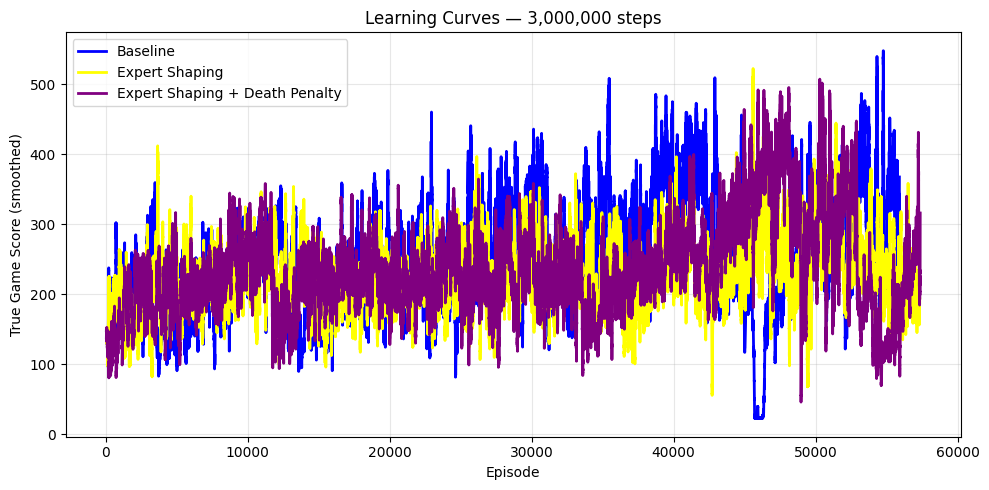

In [11]:
def smooth(arr, window = 50):
    arr = np.asarray(arr, dtype = float)
    if len(arr) < window:
        return arr
    return np.convolve(arr, np.ones(window) / window, mode="valid")

def steps_to_threshold(
    episode_rewards,
    episode_lengths,
    threshold,
    window = 50,
):
    rewards = np.asarray(episode_rewards, dtype=float)
    lengths = np.asarray(episode_lengths, dtype=float)
    smoothed = smooth(rewards, window)
    above = np.where(smoothed >= threshold)[0]
    if len(above) == 0:
        return None, None
    ep_idx = int(above[0]) + (window - 1)
    step_count = int(np.sum(lengths[: ep_idx + 1]))
    return ep_idx, step_count
 
print(f"Learning Efficiency — {TOTAL_STEPS:,} steps")
efficiency = {}
 
for name, data in results.items():
    if data is None:
        continue
    rewards = np.asarray(data["episode_rewards"], dtype=float)
    smoothed = smooth(rewards, window=50)
    own_best = float(np.max(smoothed)) if len(smoothed) else 0.0
    threshold = 0.5 * own_best
    final_avg = float(np.mean(rewards[-100:])) if len(rewards) >= 100 else float(np.mean(rewards))
    ep, steps = steps_to_threshold(rewards, data["episode_lengths"], threshold)
    efficiency[name] = {
        "threshold": round(threshold, 1),
        "episodes_to_threshold": ep,
        "steps_to_threshold": steps,
        "final_train_avg": round(final_avg, 1),
        "eval_score": round(float(np.mean(eval_results[name]["scores"])), 1) if name in eval_results else None,
    }
 
display(pd.DataFrame({
    name: {
        "Threshold": e["threshold"],
        "Episodes": e["episodes_to_threshold"] or "Never",
        "Steps": f"{e['steps_to_threshold']:,}" if e["steps_to_threshold"] else "Never",
        "Train Avg": e["final_train_avg"],
        "Eval Score": e["eval_score"],
    }
    for name, e in efficiency.items()
}).T)

def plot_learning_curves(results, CONDITIONS, TOTAL_STEPS):
    fig, ax = plt.subplots(figsize=(10, 5))
    
    for name, data in results.items():
        if data is None:
            continue
        rewards = pd.Series(data["episode_rewards"])
        ax.plot(rewards.rolling(50).mean(), 
                color=CONDITIONS[name]["color"], 
                linewidth=2, label=name)
    
    ax.set_xlabel("Episode")
    ax.set_ylabel("True Game Score (smoothed)")
    ax.set_title(f"Learning Curves — {TOTAL_STEPS:,} steps")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(f"plot_learning_curves_{TOTAL_STEPS // 1_000_000}M.png", dpi=130)
    plt.show()

plot_learning_curves(results, CONDITIONS, TOTAL_STEPS)

## Score Distribution Box Plot

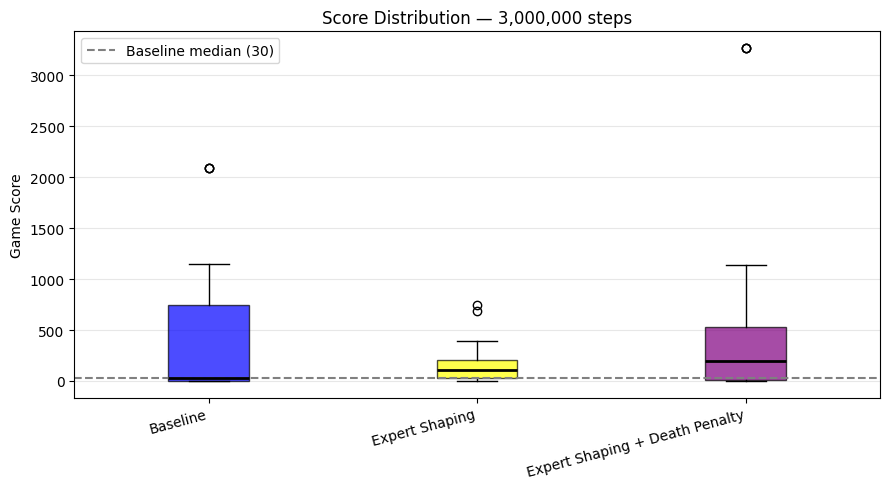

In [12]:
def plot_score_distribution(eval_results, CONDITIONS, TOTAL_STEPS):
    fig, ax = plt.subplots(figsize=(9, 5))
    
    names = list(eval_results.keys())
    colors = [CONDITIONS[n]["color"] for n in names]
    
    bp = ax.boxplot([eval_results[n]["scores"] for n in names],
                    patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    if "Baseline" in eval_results:
        bm = np.median(eval_results["Baseline"]["scores"])
        ax.axhline(bm, color="gray", linestyle="--", linewidth=1.5,
                   label=f"Baseline median ({bm:.0f})")

    ax.set_xticks(range(1, len(names) + 1))
    ax.set_xticklabels(names, rotation=15, ha="right")
    ax.set_ylabel("Game Score")
    ax.set_title(f"Score Distribution — {TOTAL_STEPS:,} steps")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(f"plot_score_distribution_{TOTAL_STEPS // 1_000_000}M.png", dpi=130)
    plt.show()

plot_score_distribution(eval_results, CONDITIONS, TOTAL_STEPS)

## Statistical Summary 

In [13]:
print(f"\nFULL STATISTICAL SUMMARY-{TOTAL_STEPS // 1_000_000}M steps")

display(pd.DataFrame({
    name: {
        "Mean Score": round(np.mean(er["scores"]), 1),
        "Std": round(np.std(er["scores"]), 1),
        "Max Score": int(np.max(er["scores"])),
        "Survival": round(np.mean(er["lengths"]), 1),
        "Ghost Chain": round(np.mean(er["ghost_chains"]), 2),
        "Ghosts/ep": round(np.mean(er.get("ghosts_eaten_total", [0])), 1),
        "Score/step": round(np.mean(er["score_per_step"]), 3),
    }
    for name, er in eval_results.items()
}).T)

# Baseline comparison table 
if "Baseline" in eval_results:
    b_score = np.mean(eval_results["Baseline"]["scores"])
    b_length = np.mean(eval_results["Baseline"]["lengths"])

    print(f"\nComparison vs Baseline")
    display(pd.DataFrame({
        name: {
            "Score Diff": round(np.mean(er["scores"]) - b_score,  1),
            "Beats BL?": "YES" if np.mean(er["scores"]) > b_score  else "NO",
            "Survival Diff":round(np.mean(er["lengths"]) - b_length, 1),
            "Survival Dir": "↑" if np.mean(er["lengths"]) - b_length > 1
                            else "↓" if np.mean(er["lengths"]) - b_length < -1
                            else "=",
        }
        for name, er in eval_results.items()
    }).T)


FULL STATISTICAL SUMMARY-3M steps


,Mean Score,Std,Max Score,Survival,Ghost Chain,Ghosts/ep,Score/step
Baseline,364.3,531.6,2090.0,52.8,0.16,0.0,4.296
Expert Shaping,121.9,123.7,750.0,52.1,0.05,0.0,2.117
Expert Shaping + Death Penalty,393.2,613.5,3270.0,52.6,0.16,0.0,5.733



Comparison vs Baseline


,Score Diff,Beats BL?,Survival Diff,Survival Dir
Baseline,0.0,NO,0.0,=
Expert Shaping,-242.4,NO,-0.7,=
Expert Shaping + Death Penalty,28.9,YES,-0.3,=


## Reward Hacking Detection 

In [14]:
if results.get("Baseline") is None or eval_results.get("Baseline") is None:
    raise ValueError("Baseline results missing, run Baseline training first.")
 
baseline_train = float(np.mean(results["Baseline"]["episode_rewards"][-100:]))
baseline_eval = float(np.mean(eval_results["Baseline"]["scores"]))
 
hacking = {}
for name, data in results.items():
    if data is None or name not in eval_results:
        continue
    train_r = float(np.mean(data["episode_rewards"][-100:]))
    eval_s  = float(np.mean(eval_results[name]["scores"]))
    ratio   = round(eval_s / train_r, 2) if train_r > 0 else 1.0
 
    if name == "Baseline":
        verdict = "Reference"
    elif train_r > baseline_train and eval_s < baseline_eval and ratio < 0.6:
        verdict = "HACKING"
    elif train_r > baseline_train and eval_s < baseline_eval:
        verdict = "LIKELY"
    elif eval_s < baseline_eval:
        verdict = "Underperforms"
    else:
        verdict = "Clean"
 
    hacking[name] = {
        "Train Reward": round(train_r, 1),
        "Eval Score": round(eval_s, 1),
        "Ratio": ratio,
        "vs BL": round(eval_s - baseline_eval, 1),
        "Verdict": verdict,
    }
 
print(f"\nREWARD HACKING ANALYSIS — {TOTAL_STEPS:,} steps")
print("Ratio = eval / train  (1.0 = aligned, <0.6 = likely hacking)")
display(pd.DataFrame(hacking).T)


REWARD HACKING ANALYSIS — 3,000,000 steps
Ratio = eval / train  (1.0 = aligned, <0.6 = likely hacking)


,Train Reward,Eval Score,Ratio,vs BL,Verdict
Baseline,348.9,364.3,1.04,0.0,Reference
Expert Shaping,187.9,121.9,0.65,-242.4,Underperforms
Expert Shaping + Death Penalty,261.3,393.2,1.5,28.9,Clean


## Research Question Answer Matrix

In [15]:
b_score  = float(np.mean(eval_results["Baseline"]["scores"]))
b_length = float(np.mean(eval_results["Baseline"]["lengths"]))
b_chain  = float(np.mean(eval_results["Baseline"]["ghost_chains"]))
b_sp = float(np.mean(eval_results["Baseline"]["score_per_step"]))
b_ghosts = float(np.mean(eval_results["Baseline"]["ghosts_eaten"]))
b_train  = float(np.mean(results["Baseline"]["episode_rewards"][-100:]))
 
def _arrow(delta, threshold=0.5):
    if delta >  threshold: return "↑"
    if delta < -threshold: return "↓"
    return "="
 
print(f"\nRQ1: Does strategy-informed shaping outperform baseline? — {TOTAL_STEPS:,} steps")
display(pd.DataFrame({
    name: {
        "Eval Score": round(float(np.mean(er["scores"])), 1),
        "vs Baseline": round(float(np.mean(er["scores"])) - b_score, 1),
        "Verdict": (
            "Reference" if name == "Baseline" else
            "BEATS" if float(np.mean(er["scores"])) > b_score else
            "Similar" if float(np.mean(er["scores"])) > b_score - 20 else
            "BELOW"
        ),
    }
    for name, er in eval_results.items()
}).T)
 
print("\nRQ2: Did shaping alter behaviour beyond score?")
display(pd.DataFrame({
    name: {
        "Survival": f"{_arrow(d := float(np.mean(er['lengths'])) - b_length)}{d:+.1f}",
        "Chain": f"{_arrow(d := float(np.mean(er['ghost_chains'])) - b_chain, 0.05)}{d:+.2f}",
        "Ghosts/ep": f"{_arrow(d := float(np.mean(er['ghosts_eaten'])) - b_ghosts, 0.05)}{d:+.2f}",
        "Score/step": f"{_arrow(d := float(np.mean(er['score_per_step'])) - b_sp, 0.001)}{d:+.3f}",
    }
    for name, er in eval_results.items()
}).T)
 
print("\nRQ3: Evidence of reward hacking?")
display(pd.DataFrame({
    name: {
        "Train": round(t := float(np.mean(data["episode_rewards"][-100:])), 1),
        "Eval": round(e := float(np.mean(eval_results[name]["scores"])), 1),
        "Ratio": round(e / t if t > 0 else 1.0, 2),
        "vs BL": round(t - b_train, 1),
        "Verdict": (
            "Reference" if name == "Baseline" else
            "HACKING" if t > b_train and e < b_score and e / t < 0.6 else
            "LIKELY" if t > b_train and e < b_score else
            "Underperforms" if e < b_score else
            "Clean"
        ),
    }
    for name, data in results.items()
    if data is not None and name in eval_results
}).T)
print("Ratio = eval/train  (1.0 = clean, <0.6 = hacking)")


RQ1: Does strategy-informed shaping outperform baseline? — 3,000,000 steps


,Eval Score,vs Baseline,Verdict
Baseline,364.3,0.0,Reference
Expert Shaping,121.9,-242.4,BELOW
Expert Shaping + Death Penalty,393.2,28.9,BEATS



RQ2: Did shaping alter behaviour beyond score?


,Survival,Chain,Ghosts/ep,Score/step
Baseline,=+0.0,=+0.00,=+0.00,=+0.000
Expert Shaping,↓-0.7,↓-0.11,↓-0.18,↓-2.179
Expert Shaping + Death Penalty,=-0.3,=+0.00,↓-0.07,↑+1.438



RQ3: Evidence of reward hacking?


,Train,Eval,Ratio,vs BL,Verdict
Baseline,348.9,364.3,1.04,0.0,Reference
Expert Shaping,187.9,121.9,0.65,-161.0,Underperforms
Expert Shaping + Death Penalty,261.3,393.2,1.5,-87.6,Clean


Ratio = eval/train  (1.0 = clean, <0.6 = hacking)


## Evaluation of the saved models

In [16]:
TOTAL_STEPS = 1_000_000
steps_str   = f"{TOTAL_STEPS // 1_000_000}M"
 
NAME_TO_SLUG = {
    "Baseline": "baseline",
    "Expert Shaping": "expert_shaping",
    "Expert Shaping + Death Penalty": "expert_shaping__death_penalty",
}
 
eval_results = {}
results = {}
 
for name, slug in NAME_TO_SLUG.items():
    model_path = f"ppo_pacman_{slug}_{steps_str}"
    training_path = f"training_{slug}_{steps_str}.json"
    eval_path = f"eval_{slug}_{steps_str}.json"
 
    # load model
    try:
        model = PPO.load(model_path)
        print(f"Loaded {model_path}.zip")
    except FileNotFoundError:
        print(f"  {model_path}.zip not found — skipping {name}")
        results[name] = None
        continue
 
    # ── evaluate (or use cached result) 
    if os.path.exists(eval_path):
        with open(eval_path) as f:
            raw = json.load(f)
        er = {k: np.array(v) for k, v in raw.items() if k not in ("condition", "steps")}
        print(f"  Eval loaded from cache: {eval_path}")
    else:
        er = evaluate_agent(model, n_episodes=100, seed=99)
        with open(eval_path, "w") as f:
            json.dump({k: v.tolist() for k, v in er.items()} | {"condition": name, "steps": TOTAL_STEPS}, f)
        print(f"  Eval complete + saved: {eval_path}")
    eval_results[name] = er
 
    # ── load training log 
    if os.path.exists(training_path):
        with open(training_path) as f:
            td = json.load(f)
        results[name] = {
            "episode_rewards": td["episode_rewards"],
            "episode_shaped_rewards": td.get("episode_shaped_rewards", td["episode_rewards"]),
            "episode_lengths": td["episode_lengths"],
            "episode_ghosts_eaten": td.get("episode_ghosts_eaten", []),
            "total_steps": TOTAL_STEPS,
            "model": model,
        }
        print(f"  Training log loaded:  {training_path}")
    else:
        print(f"  No training log found — plots will be empty for {name}")
        results[name] = {
            "episode_rewards": [], "episode_shaped_rewards": [],
            "episode_lengths": [], "episode_ghosts_eaten": [],
            "total_steps": TOTAL_STEPS, "model": model,
        }
    print()
 
# Summary
display(pd.DataFrame({
    name: {
        "Avg Score": round(float(np.mean(er["scores"])), 1),
        "Std": round(float(np.std(er["scores"])), 1),
        "Survival": round(float(np.mean(er["lengths"])), 1),
        "Ghost Chain": round(float(np.mean(er["ghost_chains"])), 2),
        "Ghosts/ep": round(float(np.mean(er["ghosts_eaten"])), 1),
        "Score/step": round(float(np.mean(er["score_per_step"])), 3),
    }
    for name, er in eval_results.items()
}).T)
print(f"\n{len(eval_results)} conditions loaded {TOTAL_STEPS:,} steps")

  ppo_pacman_baseline_1M.zip not found — skipping Baseline
  ppo_pacman_expert_shaping_1M.zip not found — skipping Expert Shaping
  ppo_pacman_expert_shaping__death_penalty_1M.zip not found — skipping Expert Shaping + Death Penalty


""



0 conditions loaded 1,000,000 steps
